# Remaining Useful Life (RUL) Prediction using Bidirectional LSTM

This notebook implements a **Bidirectional LSTM (Bi-LSTM)** deep learning model to predict the Remaining Useful Life of aircraft engines using the NASA C-MAPSS dataset.

### **Enhanced Features:**
1. **Detailed Naming**: Using physical sensor names (T2, T24, etc.) for better interpretability.
2. **NASA S-Score**: Implementation of the competition-standard scoring metric.
3. **Advanced EDA**: Correlation analysis and descriptive statistics.
4. **Data Preprocessing**: RUL clipping at 125 cycles and sliding window transformations.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded. TensorFlow version:", tf.__version__)

Libraries loaded. TensorFlow version: 2.21.0


## 1. Data Loading
We use the standard C-MAPSS column names for sensors and operational settings.

In [2]:
dataset_path = 'C-MPASS/DATASET/'

columns = ['unit_ID', 'cycles', 'setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']

def load_data(filename):
    df = pd.read_csv(os.path.join(dataset_path, filename), sep='\s+', header=None, names=columns)
    return df

train_df = load_data('train_FD001.txt')
test_df = load_data('test_FD001.txt')
true_rul = pd.read_csv(os.path.join(dataset_path, 'RUL_FD001.txt'), sep='\s+', header=None, names=['RUL'])

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

Train Shape: (20631, 26)
Test Shape: (13096, 26)


## 2. Exploratory Data Analysis (EDA)

### **2.1 Descriptive Statistics**

In [3]:
train_df.describe()

,unit_ID,cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


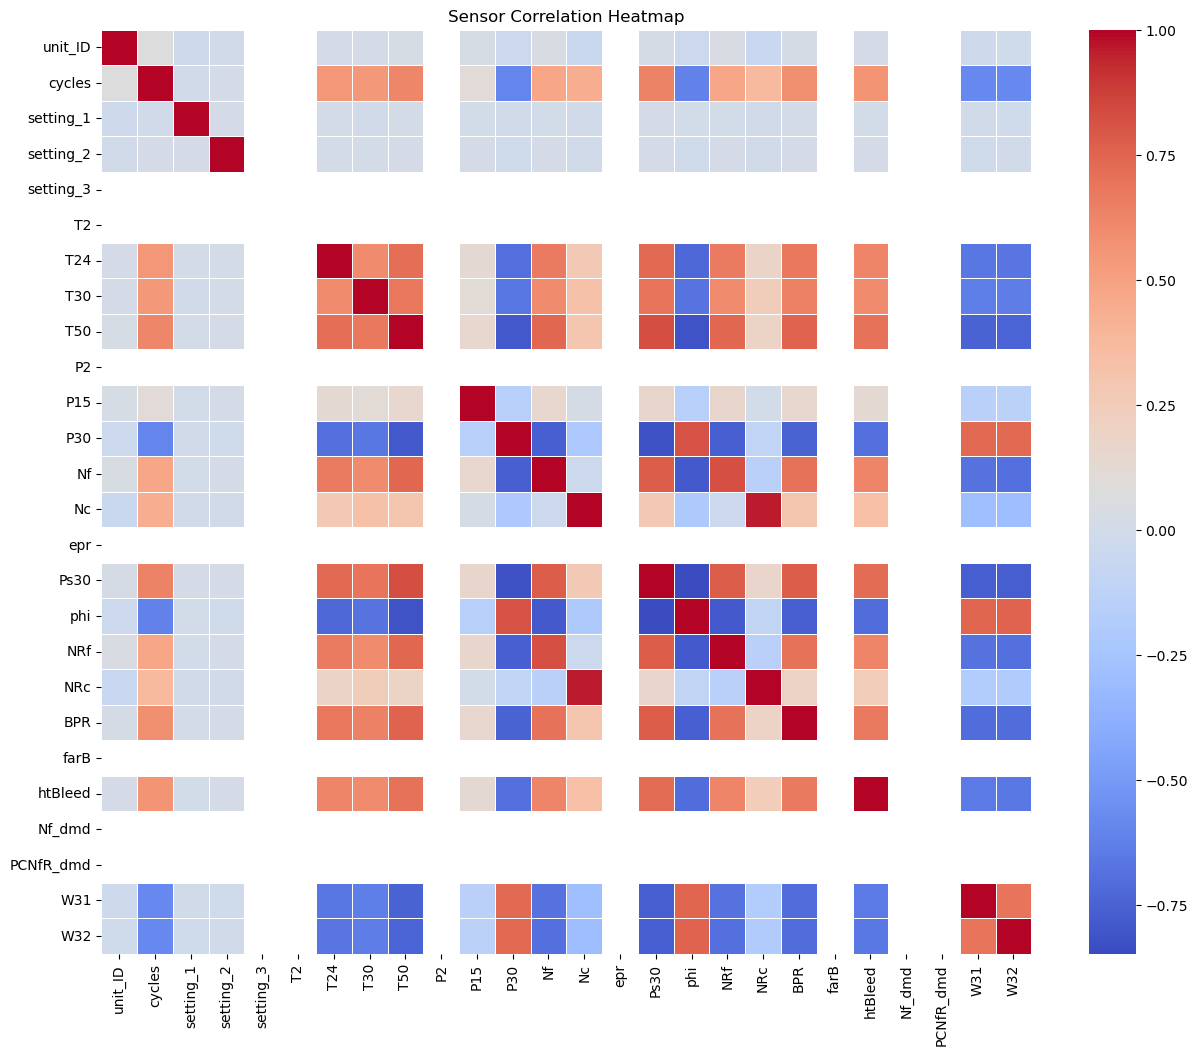

In [4]:
plt.figure(figsize=(15, 12))
sns.heatmap(train_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Sensor Correlation Heatmap')
plt.show()

## 3. Data Preprocessing & Feature Engineering

### **3.1 Calculate RUL**
Applying **RUL Clipping** at 125 cycles.

In [5]:
def add_rul(df):
    max_cycles = df.groupby('unit_ID')['cycles'].max().reset_index()
    max_cycles.columns = ['unit_ID', 'max_cycle']
    df = df.merge(max_cycles, on='unit_ID')
    df['RUL'] = df['max_cycle'] - df['cycles']
    df.drop('max_cycle', axis=1, inplace=True)
    df['RUL'] = df['RUL'].clip(upper=125)
    return df

train_df = add_rul(train_df)
print("RUL calculation and clipping applied.")

RUL calculation and clipping applied.


In [6]:
std_devs = train_df.std()
cols_to_drop = std_devs[std_devs == 0].index.tolist()
train_df.drop(cols_to_drop, axis=1, inplace=True)
test_df.drop(cols_to_drop, axis=1, inplace=True)

features = [c for c in train_df.columns if c not in ['unit_ID', 'cycles', 'RUL']]
scaler = MinMaxScaler()
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

print(f"Dropped: {cols_to_drop}")
print(f"Remaining Features: {len(features)}")

Dropped: ['setting_3', 'Nf_dmd', 'PCNfR_dmd']
Remaining Features: 21


### **3.3 Sequence Creation**
Preparing 3D input for Bi-LSTM.

In [7]:
window_size = 30

def gen_sequences(df, seq_length, seq_cols):
    data_array = df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length + 1), range(seq_length, num_elements + 1)):
        yield data_array[start:stop, :]

def gen_labels(df, seq_length, label_cols):
    data_array = df[label_cols].values
    num_elements = data_array.shape[0]
    return data_array[seq_length - 1:num_elements, :]

x_train_list = []
y_train_list = []
for i in train_df['unit_ID'].unique():
    unit_data = train_df[train_df['unit_ID']==i]
    if len(unit_data) >= window_size:
        x_train_list.extend(list(gen_sequences(unit_data, window_size, features)))
        y_train_list.extend(list(gen_labels(unit_data, window_size, ['RUL'])))

x_train = np.array(x_train_list).astype(np.float32)
y_train = np.array(y_train_list).astype(np.float32)

x_test_list = []
y_test_list = []
for i in test_df['unit_ID'].unique():
    unit_data = test_df[test_df['unit_ID']==i]
    if len(unit_data) >= window_size:
        x_test_list.append(unit_data[features].values[-window_size:])
        y_test_list.append(true_rul.values[i-1]) # test_df units are 1-indexed

x_test = np.array(x_test_list).astype(np.float32)
y_test = np.array(y_test_list).astype(np.float32)

print(f"X_train shape: {x_train.shape}")
print(f"X_test shape: {x_test.shape}")

X_train shape: (17731, 30, 21)
X_test shape: (100, 30, 21)


## 4. Bidirectional LSTM Model


In [8]:
model = Sequential([
    Input(shape=(window_size, len(features))),
    Bidirectional(LSTM(100, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(50)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━┳━━━━━━┳━━━━┓
┃ Layer   ┃ Out… ┃ P… ┃
┃ (type)  ┃ Sha… ┃  # ┃
┡━━━━━━━━━╇━━━━━━╇━━━━┩
│ bidire… │ (No… │ 9… │
│ (Bidir… │ 30,  │    │
│         │ 200) │    │
├─────────┼──────┼────┤
│ dropout │ (No… │  0 │
│ (Dropo… │ 30,  │    │
│         │ 200) │    │
├─────────┼──────┼────┤
│ bidire… │ (No… │ 1… │
│ (Bidir… │ 100) │    │
├─────────┼──────┼────┤
│ dropou… │ (No… │  0 │
│ (Dropo… │ 100) │    │
├─────────┼──────┼────┤
│ dense   │ (No… │ 3… │
│ (Dense) │ 32)  │    │
├─────────┼──────┼────┤
│ dense_1 │ (No… │ 33 │
│ (Dense) │ 1)   │    │
└─────────┴──────┴────┘

 Total params: 201,265 (786.19 KB)

 Trainable params: 201,265 (786.19 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training & Evaluation

In [9]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50


  1/125 ━━━━━━━━━━━━━━━━━━━━ 7:44 4s/step - loss: 7996.2979 - mae: 79.4981

  2/125 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - loss: 7909.2603 - mae: 79.0589

  3/125 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 7889.1157 - mae: 78.9912 

  4/125 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 7864.0929 - mae: 78.7991

...

122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 153.5867 - mae: 9.0574

123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 153.5890 - mae: 9.0572

124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 153.5916 - mae: 9.0570

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 153.5932 - mae: 9.0568

125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - loss: 153.7907 - mae: 9.0288 - val_loss: 203.8084 - val_mae: 10.4942


1/4 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 576ms/step


RMSE: 13.67
MAE: 10.53
NASA S-Score: 301.79


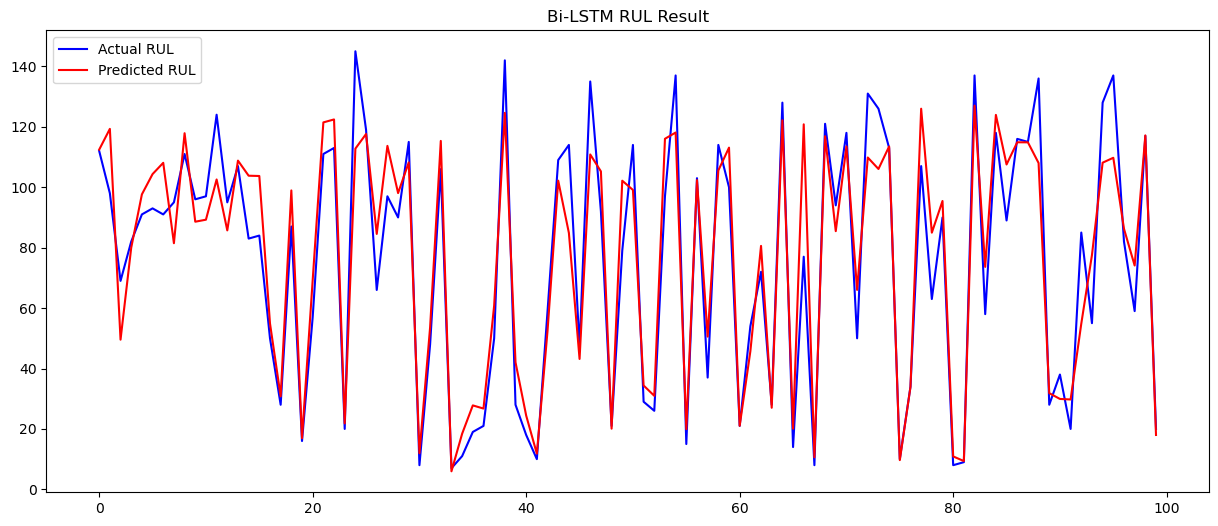

In [10]:
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

def compute_s_score(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

s_score = compute_s_score(y_test.flatten(), y_pred.flatten())

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"NASA S-Score: {s_score:.2f}")

plt.figure(figsize=(15, 6))
plt.plot(y_test, color='blue', label='Actual RUL')
plt.plot(y_pred, color='red', label='Predicted RUL')
plt.title('Bi-LSTM RUL Result')
plt.legend()
plt.show()